# Solving the XOR Problem with a Neural Network

A from-scratch implementation of a small feed-forward **neural network** trained with
**backpropagation** to learn the classic **XOR** logic function — using nothing but
[NumPy](https://numpy.org/).

The XOR ("exclusive or") function is the textbook example of a problem that a single-layer
perceptron *cannot* solve, because the two classes are **not linearly separable**. Adding a
single hidden layer with a non-linear activation is enough to crack it, which makes XOR the
"hello world" of multi-layer neural networks.

---

## What this notebook covers

1. **Background** — why XOR needs a hidden layer
2. **Dataset** — the XOR truth table
3. **Activation function** — the sigmoid and its derivative
4. **Network architecture** — a clean, reusable `XORNeuralNetwork` class
5. **Training** — forward pass, backpropagation, and loss tracking
6. **Results** — evaluating the trained network
7. **Visualization** — the training loss curve and the learned decision boundary

> **Architecture:** `2` inputs &rarr; `2` hidden units (sigmoid) &rarr; `1` output (sigmoid)

## Background: why is XOR hard?

The XOR function returns `1` only when its two inputs **differ**:

| Input 1 | Input 2 | XOR output |
|:-------:|:-------:|:----------:|
|    0    |    0    |     0      |
|    0    |    1    |     1      |
|    1    |    0    |     1      |
|    1    |    1    |     0      |

If you plot these four points, the two `1`s sit on one diagonal and the two `0`s on the other.
No single straight line can separate them, so a linear model (a single perceptron) is doomed to
fail. A network with one **hidden layer** can bend the decision surface into the non-linear shape
required to separate the classes — and that is exactly what we build below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Seed the random number generator so results are reproducible across runs.
RNG_SEED = 42
np.random.seed(RNG_SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. The dataset

We encode the XOR truth table as a feature matrix `X` (4 samples &times; 2 features) and a
target vector `y` (4 samples &times; 1 output).

In [2]:
# XOR truth table
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=float)

print("Inputs (X):")
print(X.astype(int))
print("\nTargets (y):")
print(y.ravel().astype(int))

Inputs (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Targets (y):
[0 1 1 0]


## 2. The activation function

We use the **sigmoid** function, which squashes any real number into the range `(0, 1)`:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Backpropagation needs its derivative. A convenient property of the sigmoid is that its
derivative can be written in terms of its own output $a = \sigma(z)$:

$$\sigma'(z) = a\,(1 - a)$$

In [3]:
def sigmoid(z):
    """Logistic sigmoid activation."""
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative(a):
    """Derivative of the sigmoid, expressed in terms of its output ``a = sigmoid(z)``."""
    return a * (1.0 - a)

## 3. The network

We wrap the model in a small, reusable `XORNeuralNetwork` class. It has a `2 -> 2 -> 1`
architecture and exposes the three operations every neural network needs:

- **`forward`** — propagate inputs through the layers to produce a prediction.
- **`backward`** — compute gradients via backpropagation and update the weights (gradient
  descent on the mean squared error).
- **`train`** — repeat forward/backward for a number of epochs while recording the loss.

Keeping the weights and biases as attributes (`W1`, `b1`, `W2`, `b2`) makes the math easy to
follow and lets us reuse the trained model later for prediction and plotting.

In [4]:
class XORNeuralNetwork:
    """A minimal 2-2-1 fully-connected network trained with backpropagation."""

    def __init__(self, n_input=2, n_hidden=2, n_output=1, learning_rate=0.5, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.learning_rate = learning_rate

        # Weights are drawn from a uniform distribution; biases start random too.
        self.W1 = np.random.rand(n_input, n_hidden)
        self.b1 = np.random.rand(n_hidden)
        self.W2 = np.random.rand(n_hidden, n_output)
        self.b2 = np.random.rand(n_output)

        self.loss_history = []

    def forward(self, X):
        """Run a forward pass and cache the activations for backpropagation."""
        self.a1 = sigmoid(X @ self.W1 + self.b1)   # hidden layer activation
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)  # output layer activation
        return self.a2

    def backward(self, X, y, output):
        """Backpropagate the error and update weights and biases in place."""
        # Output layer
        delta_output = (y - output) * sigmoid_derivative(output)
        # Hidden layer
        delta_hidden = (delta_output @ self.W2.T) * sigmoid_derivative(self.a1)

        # Gradient descent updates
        self.W2 += self.a1.T @ delta_output * self.learning_rate
        self.b2 += np.sum(delta_output, axis=0) * self.learning_rate
        self.W1 += X.T @ delta_hidden * self.learning_rate
        self.b1 += np.sum(delta_hidden, axis=0) * self.learning_rate

    def train(self, X, y, epochs=10000, log_every=1000):
        """Train for ``epochs`` iterations, recording the MSE loss each step."""
        for epoch in range(1, epochs + 1):
            output = self.forward(X)
            loss = np.mean((y - output) ** 2)
            self.loss_history.append(loss)
            self.backward(X, y, output)

            if log_every and (epoch == 1 or epoch % log_every == 0):
                print(f"Epoch {epoch:>6} / {epochs}  |  MSE loss: {loss:.6f}")
        return self.loss_history

    def predict(self, X):
        """Return the network's raw output for the given inputs."""
        return self.forward(X)

## 4. Training the network

We create the model with a learning rate of `0.5` and train it for `10,000` epochs on the XOR
data. The loss should drop steadily toward zero.

In [5]:
model = XORNeuralNetwork(learning_rate=0.5, seed=RNG_SEED)

print("Initial weights:")
print("  W1 (input -> hidden):\n", model.W1)
print("  W2 (hidden -> output):\n", model.W2)
print("\nTraining...\n")

loss_history = model.train(X, y, epochs=10000, log_every=1000)

print("\nTraining complete.")

Initial weights:
  W1 (input -> hidden):
 [[0.37454012 0.95071431]
 [0.73199394 0.59865848]]
  W2 (hidden -> output):
 [[0.05808361]
 [0.86617615]]

Training...

Epoch      1 / 10000  |  MSE loss: 0.324659
Epoch   1000 / 10000  |  MSE loss: 0.012614
Epoch   2000 / 10000  |  MSE loss: 0.002548
Epoch   3000 / 10000  |  MSE loss: 0.001346
Epoch   4000 / 10000  |  MSE loss: 0.000902
Epoch   5000 / 10000  |  MSE loss: 0.000675
Epoch   6000 / 10000  |  MSE loss: 0.000537
Epoch   7000 / 10000  |  MSE loss: 0.000446
Epoch   8000 / 10000  |  MSE loss: 0.000380
Epoch   9000 / 10000  |  MSE loss: 0.000331


Epoch  10000 / 10000  |  MSE loss: 0.000293

Training complete.


## 5. Results

After training, the network's outputs should be very close to the XOR targets: near `0` for
matching inputs and near `1` for differing inputs. We round the raw output at `0.5` to get the
predicted class.

In [6]:
predictions = model.predict(X)

print(f"{'Input':<10}{'Target':<10}{'Raw output':<14}{'Predicted':<10}")
print("-" * 44)
for inp, target, pred in zip(X.astype(int), y.ravel().astype(int), predictions.ravel()):
    predicted_class = int(round(pred))
    mark = "OK" if predicted_class == target else "X"
    print(f"{str(inp):<10}{target:<10}{pred:<14.4f}{predicted_class:<10}{mark}")

accuracy = np.mean(np.round(predictions) == y) * 100
print(f"\nAccuracy: {accuracy:.0f}%")

Input     Target    Raw output    Predicted 
--------------------------------------------
[0 0]     0         0.0189        0         OK
[0 1]     1         0.9837        1         OK
[1 0]     1         0.9837        1         OK
[1 1]     0         0.0169        0         OK

Accuracy: 100%


## 6. Visualizing the training loss

Plotting the recorded loss shows how quickly the network learns. A smooth, monotonically
decreasing curve is a good sign that training is stable.

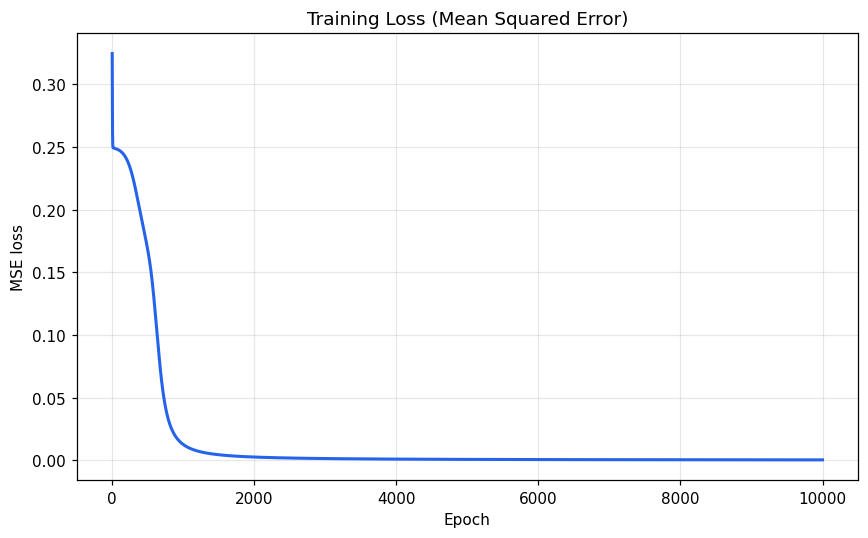

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color="#2563eb", linewidth=2)
plt.title("Training Loss (Mean Squared Error)")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Visualizing the decision boundary

Because we only have two input features, we can evaluate the trained network on a dense grid of
points and shade the input space by the network's output. The black contour marks the `0.5`
decision boundary. Notice how the network carves out a **non-linear** region — exactly what is
needed to separate the XOR classes.

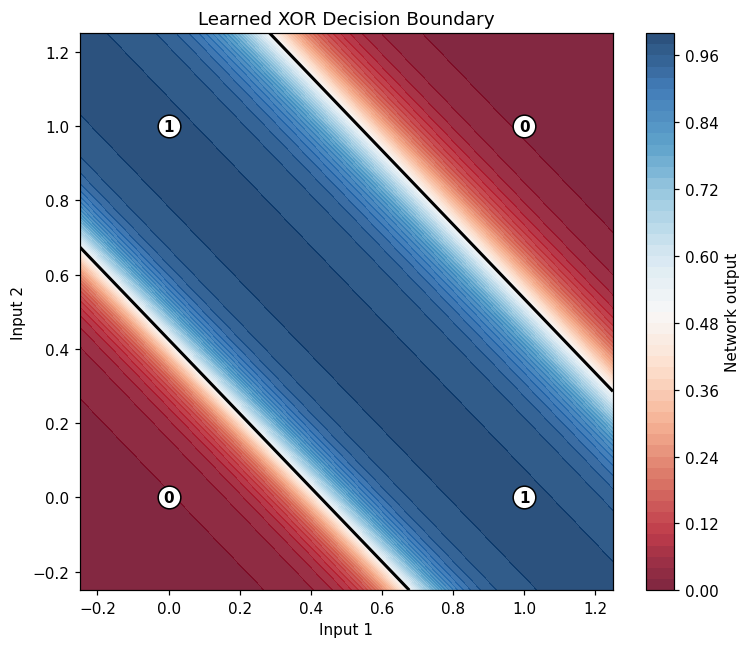

In [8]:
# Build a dense grid over the input space.
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300),
                     np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 6))
contour = plt.contourf(xx, yy, zz, levels=50, cmap="RdBu", alpha=0.85)
plt.colorbar(contour, label="Network output")
plt.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2)

# Overlay the four XOR data points, labelled with their target value.
for inp, target in zip(X, y.ravel().astype(int)):
    plt.scatter(*inp, c="white", edgecolors="black", s=220, zorder=3)
    plt.annotate(str(target), inp, ha="center", va="center", fontweight="bold")

plt.title("Learned XOR Decision Boundary")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.tight_layout()
plt.show()

## Conclusion & next steps

We built a small neural network from scratch with NumPy and trained it to solve XOR — a problem
that is impossible for a single-layer perceptron. The keys were a **hidden layer** and a
**non-linear activation** trained via **backpropagation**.

Ideas to explore further:

- Swap the sigmoid for **ReLU** or **tanh** activations and compare convergence.
- Replace MSE with **binary cross-entropy** loss.
- Add more hidden units or layers and watch how the decision boundary changes.
- Experiment with the **learning rate** and number of **epochs**.
- Try other non-linearly-separable logic gates (e.g. XNOR).